In [1]:
import os
os.environ["GITHUB_TOKEN"] = ""
!pip install --no-cache-dir "git+https://${GITHUB_TOKEN}@github.com/lueckenlab/SampleCLR.git@bb1debdff947cd2cbf05400bc36cc0ee9d90b7b0"
del os.environ["GITHUB_TOKEN"]
!pip install patpy

  Cloning https://****@github.com/lueckenlab/SampleCLR.git (to revision bb1debdff947cd2cbf05400bc36cc0ee9d90b7b0) to ./tmp/pip-req-build-4ns_lva9
  Running command git clone --filter=blob:none --quiet 'https://****@github.com/lueckenlab/SampleCLR.git' /tmp/pip-req-build-4ns_lva9


  Running command git rev-parse -q --verify 'sha^bb1debdff947cd2cbf05400bc36cc0ee9d90b7b0'
  Running command git fetch -q 'https://****@github.com/lueckenlab/SampleCLR.git' bb1debdff947cd2cbf05400bc36cc0ee9d90b7b0
  Running command git checkout -q bb1debdff947cd2cbf05400bc36cc0ee9d90b7b0
  Resolved https://****@github.com/lueckenlab/SampleCLR.git to commit bb1debdff947cd2cbf05400bc36cc0ee9d90b7b0
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.3/532.3 MB 104.3 MB/s  0:00:05eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 117.5 MB/s  0:00:030:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 117.5 MB/s  0:00:010:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 117.5 MB/s  0:00:01eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 117.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━

In [2]:
!pip install torch


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import scanpy as sc
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [4]:
import torch
import patpy
from patpy.tl import associate_embedding_with_covariates
from patpy.pl import embedding_covariate_heatmap
import sampleclr
from sampleclr.utils import (
    get_sample_representations_from_adata,
    _compute_eigenvector_centrality,
    plot_losses,
)

/opt/scanpy_venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
@torch.no_grad()
def get_cell_attention_weights(model, adata, sample_key, layer, device="cpu"):
    """Returns (n_cells, n_heads) array, aligned with adata.obs_names."""
    import scipy.sparse as sp

    # Flip aggregator into weight-returning eval mode
    old_rw = model.aggregator.return_weights
    was_train = model.aggregator.training
    model.projector.to(device).eval()
    model.aggregator.to(device).eval()
    model.aggregator.return_weights = True

    samples = adata.obs[sample_key].unique()
    all_w, all_idx = [], []

    for s in samples:
        mask = (adata.obs[sample_key] == s).values
        if not mask.any():
            continue
        feats = adata[mask].obsm[layer] if layer != "X" else adata[mask].X
        if sp.issparse(feats):  
            feats = np.asarray(feats.todense())
        x = torch.tensor(np.asarray(feats), dtype=torch.float32).unsqueeze(0).to(device)
        # aggregator returns (pooled_emb, weights); shape: (1, n_cells_in_sample, n_heads)
        _, w = model.aggregator(x)
        all_w.append(w.squeeze(0).cpu().numpy())
        all_idx.append(np.where(mask)[0])

    n_heads = all_w[0].shape[1]
    weights = np.zeros((adata.n_obs, n_heads), dtype=np.float32)
    for w, idx in zip(all_w, all_idx):
        weights[idx] = w

    # Restore aggregator state
    model.aggregator.return_weights = old_rw
    model.aggregator.train(was_train)
    return weights


In [6]:
adata = sc.read_h5ad('workspace/hpca/hpca_downstream/2026_final_object_healthy.h5ad')

In [8]:
SAMPLE_KEY = "Dataset_ID"
LAYER = "X_scanvi"
SEED = 0
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [10]:
adata.obs['Dataset_ID'] = adata.obs.Dataset.astype(str) + ' : ' + adata.obs.donor_id.astype(str)

In [12]:
len(adata.obs.Dataset_ID.unique())

109

Text(0.5, 1.0, '109 samples > 250 | 105 samples > 500 | 102 samples > 750 cells')

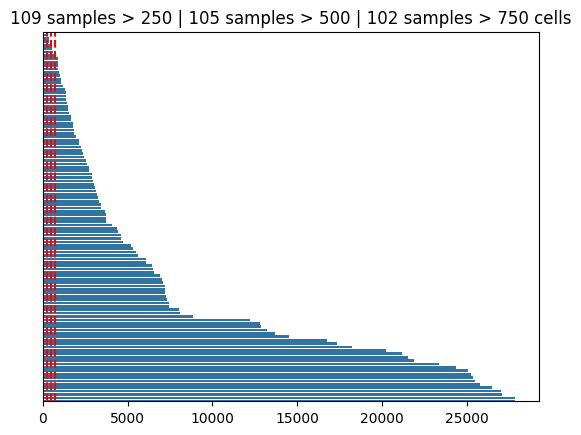

In [13]:
SAMPLE_SIZE_THRESHOLDS = [250, 500, 750]
sample_counts = adata.obs[SAMPLE_KEY].value_counts()
sns.barplot(x=sample_counts.values, y=np.arange(len(sample_counts.index)), orient="h")
plt.yticks([], [])
for thresh in SAMPLE_SIZE_THRESHOLDS:
    plt.vlines(thresh, 0, len(sample_counts.index), colors="red", linestyles="dashed")
plt.ylim(0, len(sample_counts.index))
# Create a composite title showing how many samples are above each threshold
titles = [
    f"{(sample_counts > thresh).sum()} samples > {thresh}"
    for thresh in SAMPLE_SIZE_THRESHOLDS
]
plt.title(" | ".join(titles) + " cells")

In [14]:
adata

AnnData object with n_obs × n_vars = 815126 × 24600
    obs: 'barcode', 'Dataset', 'ID', 'sample_id', 'donor_id', 'alignment_software', 'assay_ontology_term_id', 'institute', 'library_id', 'library_preparation_batch', 'library_sequencing_run', 'Manual_Annotation', 'cell_enrichment', 'condition', 'celltype_all', 'manner_of_death', 'reference_genome', 'sample_collection_method', 'sample_source', 'sampled_site_condition', 'samples', 'sex', 'sex--cell_ontology_term_id', 'suspension_type', 'technology', 'tissue_type', 'assay', 'tissue', 'organism', 'disease', 'gene_annotation_version', 'batch_covar_split', 'batch_covar_split_donor_id', 'batch_covariate', 'info_batch_covariate_split', 'doublet_score', 'predicted_doublet', 'n_genes', 'total_counts', 'total_counts_mito', 'total_counts_ribo', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'log1p_total_counts_mito', 'log1p_total_counts_ribo', 'n_genes_by_counts', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_

In [15]:
SAMPLE_SIZE_THRESHOLD = 250

In [ ]:
adata = patpy.pp.filter_small_samples(adata, SAMPLE_KEY, sample_size_threshold=SAMPLE_SIZE_THRESHOLD)
adata

0 samples removed: 


AnnData object with n_obs × n_vars = 815126 × 24600
    obs: 'barcode', 'Dataset', 'ID', 'sample_id', 'donor_id', 'alignment_software', 'assay_ontology_term_id', 'institute', 'library_id', 'library_preparation_batch', 'library_sequencing_run', 'Manual_Annotation', 'cell_enrichment', 'condition', 'celltype_all', 'manner_of_death', 'reference_genome', 'sample_collection_method', 'sample_source', 'sampled_site_condition', 'samples', 'sex', 'sex--cell_ontology_term_id', 'suspension_type', 'technology', 'tissue_type', 'assay', 'tissue', 'organism', 'disease', 'gene_annotation_version', 'batch_covar_split', 'batch_covar_split_donor_id', 'batch_covariate', 'info_batch_covariate_split', 'doublet_score', 'predicted_doublet', 'n_genes', 'total_counts', 'total_counts_mito', 'total_counts_ribo', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'log1p_total_counts_mito', 'log1p_total_counts_ribo', 'n_genes_by_counts', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_

In [ ]:
# ---- 3. Train/val split at the SAMPLE level ----------------------------
all_ids = adata.obs[SAMPLE_KEY].unique()
train_ids, val_ids = train_test_split(all_ids, test_size=0.2, random_state=SEED)
print(f"Train samples: {len(train_ids)}, Val samples: {len(val_ids)}")

Train samples: 87, Val samples: 22


In [24]:
adata.obs.columns[adata.obs.columns.str.contains('develop', case=False)]

Index(['development_stage_ontology_term_id'], dtype='object')

In [32]:
sample_level_columns = [
 'Dataset',
 'sample_id', 
 'manner_of_death',
 'suspension_type',
 'technology',
 'assay', 'sex', 'sex--cell_ontology_term_id', 'sex_ontology_term_id','sex_meta',
 'age', 'age_unit', 'mapped_age_bin', 'age_from_hsapdv', 'development_stage_ontology_term_id',
 'gene_annotation_version',
 'batch_covar_split', 'BMI', 'HbA1c',
#  'batch_covar_split_donor_id',  # too many nans
 'batch_covariate',
#  'info_batch_covariate_split',
 'batch_covar_final']

In [30]:
sample_ids = adata.obs.Dataset_ID.unique()

In [33]:
metadata = patpy.pp.extract_metadata(
    adata,
    sample_key=SAMPLE_KEY,
    columns=sample_level_columns,
    samples=sample_ids
)
metadata

/tmp/ipykernel_419800/2281487140.py:1: UserWarning: Metadata contains multiple values for the same sample, taking only the first occurence
  metadata = patpy.pp.extract_metadata(


,Dataset,sample_id,manner_of_death,suspension_type,technology,assay,sex,sex--cell_ontology_term_id,sex_ontology_term_id,sex_meta,...,age_unit,mapped_age_bin,age_from_hsapdv,development_stage_ontology_term_id,gene_annotation_version,batch_covar_split,BMI,HbA1c,batch_covariate,batch_covar_final
Dataset_ID,,,,,,,,,,,,,,,,,,,,,
GSE101207_remapped : Non_diabetic_donor_6,GSE101207_remapped,SAMN08051215,unknown,cell,NaN,Drop-seq,NaN,PATO:0000384,PATO:0000384,NaN,...,NaN,NaN,"(40.0, 50.0)",HsapDv:0000239,NaN,GSE101207_remapped,34.6,5.4,Non_diabetic_donor_6,GSE101207_remapped
GSE101207_remapped : Non_diabetic_donor_2,GSE101207_remapped,SAMN07343862,unknown,cell,NaN,Drop-seq,NaN,PATO:0000384,PATO:0000384,NaN,...,NaN,NaN,"(20.0, 30.0)",HsapDv:0000237,NaN,GSE101207_remapped,22.8,5.2,Non_diabetic_donor_2,GSE101207_remapped
GSE101207_remapped : Non_diabetic_donor_5,GSE101207_remapped,SAMN07343859,unknown,cell,NaN,Drop-seq,NaN,PATO:0000384,PATO:0000384,NaN,...,NaN,NaN,"(20.0, 30.0)",HsapDv:0000237,NaN,GSE101207_remapped,30.8,4.9,Non_diabetic_donor_5,GSE101207_remapped
GSE101207_remapped : Non_diabetic_donor_1,GSE101207_remapped,SAMN07343863,unknown,cell,NaN,Drop-seq,NaN,PATO:0000384,PATO:0000384,NaN,...,NaN,NaN,"(20.0, 30.0)",HsapDv:0000237,NaN,GSE101207_remapped,20.6,5.4,Non_diabetic_donor_1,GSE101207_remapped
GSE101207_remapped : Non_diabetic_donor_4,GSE101207_remapped,SAMN07343860,unknown,cell,NaN,Drop-seq,NaN,PATO:0000384,PATO:0000384,NaN,...,NaN,NaN,"(50.0, 60.0)",HsapDv:0000240,NaN,GSE101207_remapped,22.0,5.6,Non_diabetic_donor_4,GSE101207_remapped
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Jimenez : 6401,Jimenez,MM_407,NaN,nucleus,snRNA,10x 3′ v3,F,NaN,PATO:0000383,NaN,...,NaN,HsapDv:0000237,"(20.0, 30.0)",HsapDv:0000237,NaN,MM_407,31.3,5.8,NaN,Jimenez
Jimenez : 6278,Jimenez,MM_400,NaN,nucleus,snRNA,10x 3′ v3,F,NaN,PATO:0000383,NaN,...,NaN,HsapDv:0000264,"(5.0, 15.0)",HsapDv:0000264,NaN,MM_400,21.3,6.3,NaN,Jimenez
Jimenez : 6234,Jimenez,MM_426,NaN,nucleus,snRNA,10x 3′ v3,F,NaN,PATO:0000383,NaN,...,NaN,HsapDv:0000237,"(20.0, 30.0)",HsapDv:0000237,NaN,MM_426,25.6,5.8,NaN,Jimenez


In [34]:
metadata_no_nan_cols = metadata.columns[metadata.notna().all()].tolist()
print("Columns with no NaN values:", metadata_no_nan_cols)

Columns with no NaN values: ['Dataset', 'sample_id', 'suspension_type', 'assay', 'sex_ontology_term_id', 'age_from_hsapdv', 'batch_covar_split', 'batch_covar_final']


In [37]:
adata.obs['finetune'] = adata.obs['sex_ontology_term_id'].astype(str) + ' : ' + adata.obs['age_from_hsapdv'].astype(str)

In [40]:
len(adata.obs['finetune'].unique())

19

In [42]:
model = sampleclr.ContrastiveModel(
    adata=adata,
    sample_key=SAMPLE_KEY,
    layer=LAYER,
    train_ids=list(train_ids),
    val_ids=list(val_ids),
    # data sampling
    batch_size=8,
    n_cells_per_sample=[250, 500],   # range; or an int for constant
    # encoder
    hidden_size=128,
    output_dim=128,
    use_concord_sampler=True,
    concord_batch_col="batch_covar_final",
    concord_Pd=0.9,
    num_layers=1,
    # aggregator (multihead attention)
    aggregator_type="multihead",
    aggregator_pooling="attention",
    aggregator_activation="relu",
    aggregator_hidden_size=128,
    aggregator_num_layers=2,
    aggregator_normalization="BatchNorm",
    aggregator_dropout=0.2,
    n_aggregator_heads=4,
    # loss / optim
    contrastive_loss="XSampleCLR",
    contrastive_loss_temperature=0.1,
    learning_rate_feature=3e-4,
    weight_decay=1e-4,
    feature_normalization="BatchNorm",
    # training control
    early_stopping_patience=100,
    num_warmup_epochs_stage1=10,
    num_warmup_epochs_stage2=10,
    seed=SEED,
    attention_sparsity_lambda=1e-5,
    # Supervised fine-tuning tasks
    tasks={"classification": ["finetune"]},
    classifier_num_layers=2,
    classifier_hidden_size=128
)

best_state, best_metric, n_s1, n_s2 = model.train(
    num_epochs_stage1=200,   # SSL contrastive
    num_epochs_stage2=0,     # >0 to add supervised heads (fine-tune)
    stage1_val_metric="loss",
    verbose=True,
)

Using MULTI ANCHOR CONCORD sampler (Pd=0.9, PkNN=0.3, k=3)
  -> 8 anchors/batch, 10 batches/epoch, grouping=random
MultiAnchorConcordSampler: 16 technical batches, 87 valid samples
Computing kNN (k=3, n_samples=87)...
kNN complete in 0.06s
Precomputing quadrants...
Quadrants precomputed in 0.01s
Ready. Targets: ib_knn=1, ib_g=5, ob_knn=0, ob_g=1
Stage 1: Contrastive-only training
Epoch 1/200 - Loss: 1.1272, Contr: 1.1271, Top1: 0.977, Top5: 1.000 | Time: 0.17s (11 batches, 10.5ms/batch)
Full Loss Report:
contrastive – train: 1.1271 – val: 0.5944
classification (finetune) – train: 0.0000 – val: 5.8718
contrastive top1 acc – train: 0.9773 – val: 0.9583
contrastive top5 acc – train: 1.0000 – val: 1.0000
Epoch 2/200 - Loss: 1.0061, Contr: 1.0061, Top1: 0.966, Top5: 1.000 | Time: 0.15s (11 batches, 9.2ms/batch)
Full Loss Report:
contrastive – train: 1.0061 – val: 0.5235
classification (finetune) – train: 0.0000 – val: 5.8679
contrastive top1 acc – train: 0.9659 – val: 1.0000
contrastive top

In [43]:
reps = get_sample_representations_from_adata(
    projector=model.projector,
    aggregator=model.aggregator,
    adata=adata,
    sample_key=SAMPLE_KEY,
    layer=LAYER,
    meta_obs_names=sample_ids,
    subset_size=1000,           # cells per sample at inference
    device=device,
    # cell_selection="eigenvector",   # or "random"
    # eigenvector_col="eigenvector_centrality",
)

In [44]:
import os
os.makedirs('workspace/hpca/hpca_downstream/Healthy_SampleCLR/', exist_ok=True)
os.chdir('workspace/hpca/hpca_downstream/Healthy_SampleCLR/')
sc.set_figure_params(dpi_save=300, frameon=False)

In [45]:
pwd

'/workspace/hpca/hpca_downstream/Healthy_SampleCLR'

In [47]:
model.contrastive_loss_weight = 0.1  # Decrease to give supervised loss more weight
best_state, best_metric, n_s1, n_s2 = model.train(
    num_epochs_stage1=0,   # SSL contrastive
    num_epochs_stage2=300,     # >0 to add supervised heads (fine-tune)
    stage2_val_metric="loss",
    verbose=True)

try:
    model.load_model(best_state)
except Exception:
    print("Failed to load model's best state")

torch.save({
    "projector": model.projector.state_dict(),
    "aggregator": model.aggregator.state_dict(),
}, "samlple_clr.pt")


Using MULTI ANCHOR CONCORD sampler (Pd=0.9, PkNN=0.3, k=3)
  -> 8 anchors/batch, 10 batches/epoch, grouping=random
MultiAnchorConcordSampler: 16 technical batches, 87 valid samples
Computing kNN (k=3, n_samples=87)...
kNN complete in 0.06s
Precomputing quadrants...
Quadrants precomputed in 0.01s
Ready. Targets: ib_knn=1, ib_g=5, ob_knn=0, ob_g=1
Stage 1: Contrastive-only training
Stage joint: training
Freezing the backbone for 10 epochs



Epoch 1/300 | Time: 0.11s (11 batches, 5.2ms/batch)
contrastive – train: 0.0131 – val: 0.0020
classification (finetune) – train: 5.6315 – val: 5.8099
contrastive top1 acc – train: 1.0000 – val: 1.0000
contrastive top5 acc – train: 1.0000 – val: 1.0000
------------------------------

Epoch 2/300 | Time: 0.11s (11 batches, 5.7ms/batch)
contrastive – train: 0.0093 – val: 0.0013
classification (finetune) – train: 5.6138 – val: 5.8094
contrastive top1 acc – train: 1.0000 – val: 1.0000
contrastive top5 acc – train: 1.0000 – val: 1.0000
------------------------------

Epoch 3/300 | Time: 0.12s (11 batches, 5.5ms/batch)
contrastive – train: 0.0092 – val: 0.0021
classification (finetune) – train: 5.6180 – val: 5.8069
contrastive top1 acc – train: 1.0000 – val: 1.0000
contrastive top5 acc – train: 1.0000 – val: 1.0000
------------------------------

Epoch 4/300 | Time: 0.12s (11 batches, 5.7ms/batch)
contrastive – train: 0.0108 – val: 0.0018
classification (finetune) – train: 5.5868 – val: 5.80

In [48]:
# Extract sample-level embeddings --------------------------------
reps_finetuned = get_sample_representations_from_adata(
    projector=model.projector,
    aggregator=model.aggregator,
    adata=adata,
    sample_key=SAMPLE_KEY,
    layer=LAYER,
    meta_obs_names=sample_ids,
    subset_size=1000,           # cells per sample at inference
    device=device,
    # cell_selection="eigenvector",   # or "random"
    # eigenvector_col="eigenvector_centrality",
)
# reps: (n_samples, output_dim) — one embedding per sample
np.save("sample_embeddings_finetuned.npy", reps_finetuned)

sample_reps_finetuned = pd.DataFrame(reps_finetuned, index=sample_ids)
sample_reps_finetuned.to_csv("sample_embeddings_ft.csv")

In [49]:
adata

AnnData object with n_obs × n_vars = 815126 × 24600
    obs: 'barcode', 'Dataset', 'ID', 'sample_id', 'donor_id', 'alignment_software', 'assay_ontology_term_id', 'institute', 'library_id', 'library_preparation_batch', 'library_sequencing_run', 'Manual_Annotation', 'cell_enrichment', 'condition', 'celltype_all', 'manner_of_death', 'reference_genome', 'sample_collection_method', 'sample_source', 'sampled_site_condition', 'samples', 'sex', 'sex--cell_ontology_term_id', 'suspension_type', 'technology', 'tissue_type', 'assay', 'tissue', 'organism', 'disease', 'gene_annotation_version', 'batch_covar_split', 'batch_covar_split_donor_id', 'batch_covariate', 'info_batch_covariate_split', 'doublet_score', 'predicted_doublet', 'n_genes', 'total_counts', 'total_counts_mito', 'total_counts_ribo', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'log1p_total_counts_mito', 'log1p_total_counts_ribo', 'n_genes_by_counts', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_

In [52]:
composition_raw = pd.crosstab(adata.obs['Dataset_ID'], adata.obs['Level_4'])
composition_prop = composition_raw.div(composition_raw.sum(axis=1), axis=0) * 100
composition_prop = composition_prop.loc[sample_ids]
composition_raw = composition_raw.loc[sample_ids]

In [53]:
meta_adata = sc.AnnData(obs=metadata.loc[sample_ids], obsm={"X_sampleclr_ssl": reps}, X=composition_prop)
meta_adata.layers['composition_raw'] = composition_raw.copy()
meta_adata.obsm["X_sampleclr_ft"] = sample_reps_finetuned.loc[sample_ids].values
meta_adata

AnnData object with n_obs × n_vars = 109 × 94
    obs: 'Dataset', 'sample_id', 'manner_of_death', 'suspension_type', 'technology', 'assay', 'sex', 'sex--cell_ontology_term_id', 'sex_ontology_term_id', 'sex_meta', 'age', 'age_unit', 'mapped_age_bin', 'age_from_hsapdv', 'development_stage_ontology_term_id', 'gene_annotation_version', 'batch_covar_split', 'BMI', 'HbA1c', 'batch_covariate', 'batch_covar_final'
    obsm: 'X_sampleclr_ssl', 'X_sampleclr_ft'
    layers: 'composition_raw'

In [54]:
sc.pp.neighbors(meta_adata, use_rep="X_sampleclr_ft", key_added="neighbors_sampleclr_ft")
sc.tl.umap(meta_adata, neighbors_key="neighbors_sampleclr_ft")
sc.tl.leiden(meta_adata, resolution=1, key_added="leiden_ft", neighbors_key="neighbors_sampleclr_ft")
sc.tl.diffmap(meta_adata, neighbors_key="neighbors_sampleclr_ft")

/tmp/ipykernel_419800/1018405509.py:3: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(meta_adata, resolution=1, key_added="leiden_ft", neighbors_key="neighbors_sampleclr_ft")


In [55]:
meta_adata.obs

,Dataset,sample_id,manner_of_death,suspension_type,technology,assay,sex,sex--cell_ontology_term_id,sex_ontology_term_id,sex_meta,...,mapped_age_bin,age_from_hsapdv,development_stage_ontology_term_id,gene_annotation_version,batch_covar_split,BMI,HbA1c,batch_covariate,batch_covar_final,leiden_ft
Dataset_ID,,,,,,,,,,,,,,,,,,,,,
GSE101207_remapped : Non_diabetic_donor_6,GSE101207_remapped,SAMN08051215,unknown,cell,NaN,Drop-seq,NaN,PATO:0000384,PATO:0000384,NaN,...,NaN,"(40.0, 50.0)",HsapDv:0000239,NaN,GSE101207_remapped,34.6,5.4,Non_diabetic_donor_6,GSE101207_remapped,2
GSE101207_remapped : Non_diabetic_donor_2,GSE101207_remapped,SAMN07343862,unknown,cell,NaN,Drop-seq,NaN,PATO:0000384,PATO:0000384,NaN,...,NaN,"(20.0, 30.0)",HsapDv:0000237,NaN,GSE101207_remapped,22.8,5.2,Non_diabetic_donor_2,GSE101207_remapped,4
GSE101207_remapped : Non_diabetic_donor_5,GSE101207_remapped,SAMN07343859,unknown,cell,NaN,Drop-seq,NaN,PATO:0000384,PATO:0000384,NaN,...,NaN,"(20.0, 30.0)",HsapDv:0000237,NaN,GSE101207_remapped,30.8,4.9,Non_diabetic_donor_5,GSE101207_remapped,2
GSE101207_remapped : Non_diabetic_donor_1,GSE101207_remapped,SAMN07343863,unknown,cell,NaN,Drop-seq,NaN,PATO:0000384,PATO:0000384,NaN,...,NaN,"(20.0, 30.0)",HsapDv:0000237,NaN,GSE101207_remapped,20.6,5.4,Non_diabetic_donor_1,GSE101207_remapped,4
GSE101207_remapped : Non_diabetic_donor_4,GSE101207_remapped,SAMN07343860,unknown,cell,NaN,Drop-seq,NaN,PATO:0000384,PATO:0000384,NaN,...,NaN,"(50.0, 60.0)",HsapDv:0000240,NaN,GSE101207_remapped,22.0,5.6,Non_diabetic_donor_4,GSE101207_remapped,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Jimenez : 6401,Jimenez,MM_407,NaN,nucleus,snRNA,10x 3′ v3,F,NaN,PATO:0000383,NaN,...,HsapDv:0000237,"(20.0, 30.0)",HsapDv:0000237,NaN,MM_407,31.3,5.8,NaN,Jimenez,1
Jimenez : 6278,Jimenez,MM_400,NaN,nucleus,snRNA,10x 3′ v3,F,NaN,PATO:0000383,NaN,...,HsapDv:0000264,"(5.0, 15.0)",HsapDv:0000264,NaN,MM_400,21.3,6.3,NaN,Jimenez,1
Jimenez : 6234,Jimenez,MM_426,NaN,nucleus,snRNA,10x 3′ v3,F,NaN,PATO:0000383,NaN,...,HsapDv:0000237,"(20.0, 30.0)",HsapDv:0000237,NaN,MM_426,25.6,5.8,NaN,Jimenez,1


In [56]:
meta_adata.obs['finetune'] = meta_adata.obs_names.map(dict(zip(adata.obs.Dataset_ID, adata.obs.finetune)))

In [57]:
meta_adata.obs['finetune']

Dataset_ID
GSE101207_remapped : Non_diabetic_donor_6    PATO:0000384 : (40.0, 50.0)
GSE101207_remapped : Non_diabetic_donor_2    PATO:0000384 : (20.0, 30.0)
GSE101207_remapped : Non_diabetic_donor_5    PATO:0000384 : (20.0, 30.0)
GSE101207_remapped : Non_diabetic_donor_1    PATO:0000384 : (20.0, 30.0)
GSE101207_remapped : Non_diabetic_donor_4    PATO:0000384 : (50.0, 60.0)
                                                        ...             
Jimenez : 6401                               PATO:0000383 : (20.0, 30.0)
Jimenez : 6278                                PATO:0000383 : (5.0, 15.0)
Jimenez : 6234                               PATO:0000383 : (20.0, 30.0)
Jimenez : 6393                               PATO:0000384 : (15.0, 20.0)
Jimenez : 6366                               PATO:0000383 : (20.0, 30.0)
Name: finetune, Length: 109, dtype: object

In [58]:
cols_to_plot = [
   "Dataset",
    "suspension_type", "finetune","BMI",	"HbA1c", "sex_ontology_term_id", "age_from_hsapdv" ]

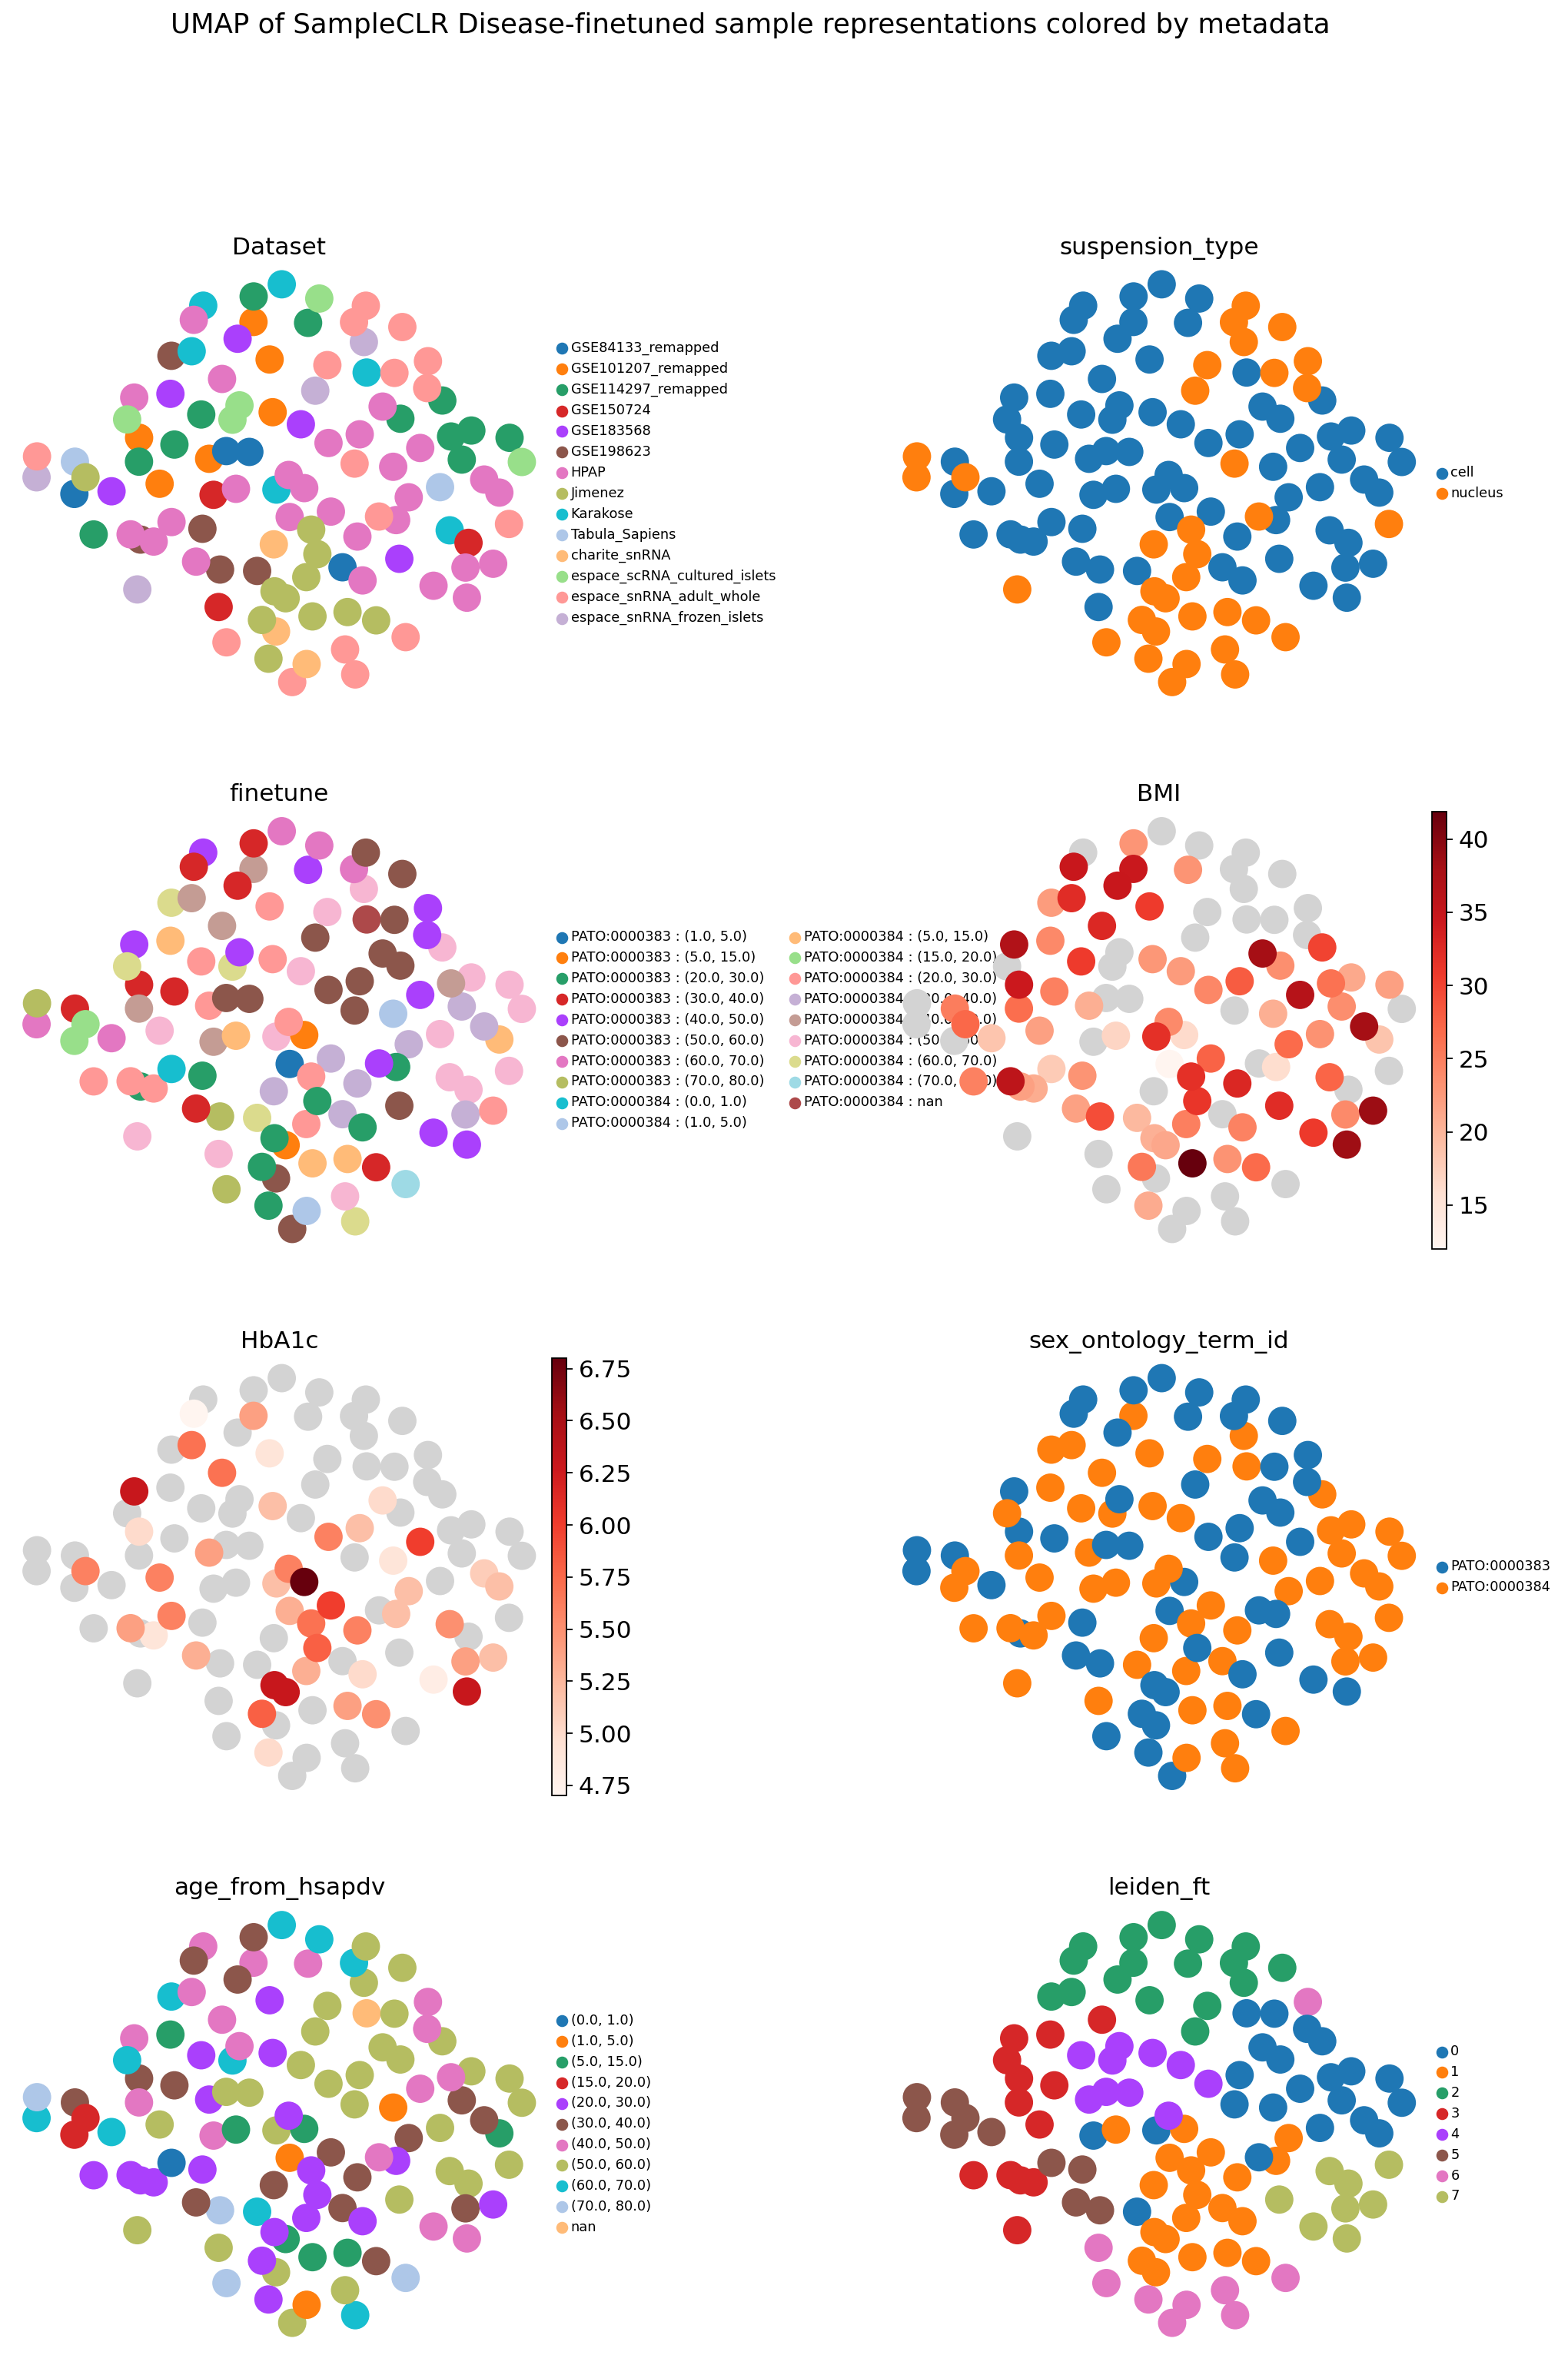

In [59]:
with plt.rc_context({"figure.figsize": (5, 5)}):
    fig = sc.pl.umap(
        meta_adata,
        color=cols_to_plot + ["leiden_ft"],
        frameon=False,
        ncols=2,
        return_fig=True,
        # palette="Set3",
        cmap="Reds",
        wspace=0.5, legend_fontsize=8,
    )
    fig.suptitle("UMAP of SampleCLR Disease-finetuned sample representations colored by metadata", fontsize=16)

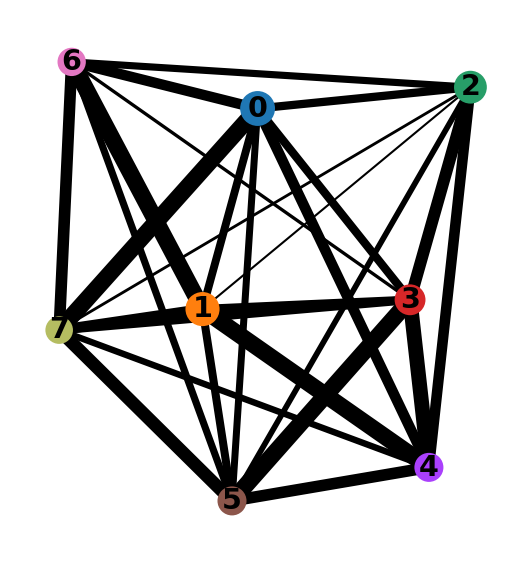

In [60]:
sc.tl.paga(meta_adata, groups='leiden_ft',  neighbors_key="neighbors_sampleclr_ft")
sc.pl.paga(meta_adata) 

In [61]:
meta_adata.write('meta_adata.h5ad')

In [62]:
pwd

'/workspace/hpca/hpca_downstream/Healthy_SampleCLR'

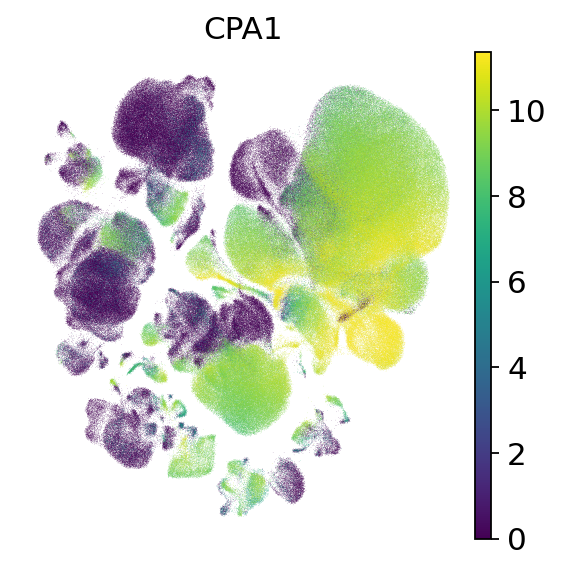

In [65]:
sc.pl.umap(adata, color='CPA1', vmax='p99', vmin='p1')